# Rendezvous: parking orbit, phasing, far-range approach and 2:1 safety ellipse

This notebook flies a complete approach with the package, end to end:

1. **Parking orbit and phasing.** The deputy starts on a lower (faster) circular parking orbit, well behind the chief. It waits there while the gap closes, then a Hohmann transfer lifts it to the chief's orbit.
2. **Hold point.** The Hohmann arrival is timed so that the deputy ends on the chief's orbit 5 km behind it, on the V-bar.
3. **Far-range rendezvous.** A two-impulse CW targeting maneuver takes the deputy from the 5 km hold point into the neighbourhood of the chief.
4. **Insertion onto a 2:1 relative ellipse.** The second burn puts the deputy on a drift-free ellipse around the chief, where it can stay without further burns.

**How the maneuvers are designed vs. how they are flown.** The designs use simple analytical tools (Hohmann for the phasing, CW targeting for the approach). The flight is *not* simulated with those tools: chief and deputy are integrated as two independent **nonlinear two-body orbits** with heyoka, in the inertial frame, and the relative motion is obtained by transforming to the chief's LVLH frame. So whatever the linear model gets wrong shows up as a real miss, which is exactly what a feasibility study needs to see.

Assumptions of this first version: two-body gravity (J2 is tried at the end), coplanar orbits, impulsive burns, circular chief orbit. Positions and velocities are in km and km/s for the inertial states, and in metres and m/s for relative (LVLH) quantities.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from ios_mission_planner.constants import MU_EARTH, R_EARTH, J2_EARTH
from ios_mission_planner.dynamics.orbital.two_body import two_body_dynamics_symbolic
from ios_mission_planner.dynamics.orbital.perturbations import two_body_j2_dynamics_symbolic
from ios_mission_planner.dynamics.relative.cw import cw_targeting
from ios_mission_planner.dynamics.relative.lvlh import inertial_to_lvlh, lvlh_rotation
from ios_mission_planner.dynamics.relative.relative_orbit import (
    RelativeOrbit, drift_free_orbit_through, relative_orbit_from_state, state_from_relative_orbit,
)
from ios_mission_planner.propagation.heyoka_propagator import propagate

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

COL_PARK = "#7f7f7f"
COL_HOH = "#ff7f0e"
COL_HOP = "#d62728"
COL_ELL = "#1f77b4"
COL_CHIEF = "#2ca02c"

## Setup: chief, parking orbit, and the phasing problem

The chief is on a circular orbit at 500 km altitude. The deputy's parking orbit is circular and coplanar at 400 km, so it is *faster* than the chief: it gains angle at a rate $n_p - n_c$ and will catch up with a chief that is initially ahead of it.

This is the same physics as the drift in the CW equations. There, a radial offset $x_{off}$ made the ellipse center slide along-track at $-\tfrac32 n\,x_{off}$; a difference in semi-major axis $\Delta a = a_p - a_c$ is exactly that offset ($x_{off} = \Delta a$), giving a relative angular drift of about $\tfrac32 n\,\Delta a / a$ per second. The phasing orbit is a way of *buying* drift with a semi-major-axis difference, and the wait in the parking orbit is where that drift is spent.

In [2]:
alt_chief, alt_park = 500.0, 400.0            # km
incl = np.deg2rad(51.6)

a_c = R_EARTH + alt_chief                      # km
a_p = R_EARTH + alt_park
n_c = np.sqrt(MU_EARTH / a_c**3)               # rad/s
n_p = np.sqrt(MU_EARTH / a_p**3)
T = 2 * np.pi / n_c                            # chief period [s]
T_park = 2 * np.pi / n_p


def circular_orbit_state(a, theta, incl):
    """Inertial state [km, km/s] on a circular orbit of radius a at argument of latitude theta."""
    p = np.array([1.0, 0.0, 0.0])
    q = np.array([0.0, np.cos(incl), np.sin(incl)])
    speed = np.sqrt(MU_EARTH / a)
    return np.concatenate([a * (np.cos(theta) * p + np.sin(theta) * q),
                           speed * (-np.sin(theta) * p + np.cos(theta) * q)])


print(f"chief   : a = {a_c:.1f} km, period = {T / 60:.2f} min")
print(f"parking : a = {a_p:.1f} km, period = {T_park / 60:.2f} min")
print(f"relative angular drift: {np.degrees(n_p - n_c) * T:.2f} deg per chief orbit "
      f"({(n_p - n_c) * T * a_c:.0f} km along-track per orbit)")

chief   : a = 6878.1 km, period = 94.62 min
parking : a = 6778.1 km, period = 92.56 min
relative angular drift: 8.00 deg per chief orbit (960 km along-track per orbit)


### Timing the Hohmann transfer

A Hohmann transfer from the parking orbit to the chief's orbit takes half a period of the transfer ellipse, $t_H$, during which the chief keeps moving by $n_c t_H$. For the deputy to arrive $s_f = 5$ km behind the chief (a *lead* of the chief of $s_f/a_c$ radians), the chief must be ahead of the deputy at departure by

$$
\varphi_{dep} = \pi - n_c\,t_H + \frac{s_f}{a_c}
$$

The deputy starts with a larger lead $\varphi_0$ (here 35 degrees), so it waits in the parking orbit until the drift has reduced the lead to $\varphi_{dep}$:

$$
t_{wait} = \frac{\varphi_0 - \varphi_{dep}}{n_p - n_c}
$$

The two burns are the usual vis-viva differences.

In [3]:
a_t = 0.5 * (a_p + a_c)
t_H = np.pi * np.sqrt(a_t**3 / MU_EARTH)

v_park = np.sqrt(MU_EARTH / a_p)
v_chief = np.sqrt(MU_EARTH / a_c)
v_t_peri = np.sqrt(MU_EARTH * (2 / a_p - 1 / a_t))
v_t_apo = np.sqrt(MU_EARTH * (2 / a_c - 1 / a_t))
dv_hohmann_1 = v_t_peri - v_park          # km/s
dv_hohmann_2 = v_chief - v_t_apo

hold_range = 5.0                          # km behind the chief
lead_departure = np.pi - n_c * t_H + hold_range / a_c
lead_initial = np.deg2rad(35.0)
t_wait = (lead_initial - lead_departure) / (n_p - n_c)

print(f"transfer time t_H      : {t_H / 60:.1f} min")
print(f"required lead at departure : {np.degrees(lead_departure):.3f} deg")
print(f"initial lead               : {np.degrees(lead_initial):.3f} deg  ({lead_initial * a_c:.0f} km ahead)")
print(f"wait in parking orbit      : {t_wait / 3600:.2f} h  ({t_wait / T_park:.2f} parking orbits)")
print(f"Hohmann burns              : {dv_hohmann_1 * 1e3:.2f} m/s and {dv_hohmann_2 * 1e3:.2f} m/s")

transfer time t_H      : 46.8 min
required lead at departure : 2.001 deg
initial lead               : 35.000 deg  (4202 km ahead)
wait in parking orbit      : 6.51 h  (4.22 parking orbits)
Hohmann burns              : 28.03 m/s and 27.92 m/s


## Flying the mission

The mission is a list of legs. Each leg is *a burn followed by a coast*, and a burn is a function that receives the actual states of both spacecraft at that instant and returns the inertial $\Delta v$. This matters for the two CW burns: they are computed from the state the deputy really has when the burn happens, exactly as onboard guidance would do, not from the state the design assumed.

- `prograde_burn`: fixed magnitude along the velocity (Hohmann 1).
- `circularize_burn`: brings the speed to the local circular speed (Hohmann 2).
- `hop_burn`: computes the first CW targeting burn from the measured relative state, aimed at the design insertion point of the ellipse. It removes a small geometric offset from the measured state first; the reason is explained (and measured) right after the results.
- `insertion_burn`: looks at where the deputy has actually arrived, takes the drift-free 2:1 ellipse that passes through that point, and matches its velocity. Insertion from the achieved point, rather than from the planned one, is what keeps the ellipse drift-free even if the hop missed by a few metres.

In [4]:
# design of the approach: ellipse and time of flight
rho_ellipse = 200.0                                   # m radial semi-axis (400 m along-track)
orbit_design = RelativeOrbit(x_off=0.0, y_c=0.0, rho=rho_ellipse, alpha=np.pi / 2)
state_design = state_from_relative_orbit(orbit_design, n_c)   # m, m/s: arrive at x = 0, y = -2 rho
T_hop = 0.75 * T
T_hold = 0.5 * T


def to_inertial_dv(chief, dv_lvlh_ms):
    """LVLH delta-v [m/s] -> inertial delta-v [km/s]."""
    return lvlh_rotation(chief).T @ dv_lvlh_ms / 1e3


def prograde_burn(dv):
    return lambda chief, deputy: dv * deputy[3:] / np.linalg.norm(deputy[3:])


def circularize_burn(chief, deputy):
    speed = np.linalg.norm(deputy[3:])
    v_circ = np.sqrt(MU_EARTH / np.linalg.norm(deputy[:3]))
    return (v_circ - speed) * deputy[3:] / speed


def hop_burn_naive(chief, deputy):
    rel = inertial_to_lvlh(chief, deputy) * 1e3
    dv1, _ = cw_targeting(rel[:3], rel[3:], state_design[:3], state_design[3:], T_hop, n_c)
    return to_inertial_dv(chief, dv1)


def hop_burn(chief, deputy):
    rel = inertial_to_lvlh(chief, deputy) * 1e3
    rel_design = rel.copy()
    rel_design[0] += rel[1] ** 2 / (2 * a_c * 1e3)     # remove the frame-curvature offset, see below
    dv1, _ = cw_targeting(rel_design[:3], rel_design[3:], state_design[:3], state_design[3:], T_hop, n_c)
    return to_inertial_dv(chief, dv1)


def insertion_burn(chief, deputy):
    rel = inertial_to_lvlh(chief, deputy) * 1e3
    orbit = drift_free_orbit_through(rel[0], rel[1])
    target = state_from_relative_orbit(orbit, n_c)
    return to_inertial_dv(chief, target[3:] - rel[3:])


def run_plan(chief0, deputy0, plan, dynamics, pars, pts=300):
    """Fly a list of (label, burn, duration) legs. Returns per-leg histories and burn events."""
    chief, deputy = np.array(chief0, dtype=float), np.array(deputy0, dtype=float)
    t_start = 0.0
    legs, events = [], []

    for label, burn, duration in plan:
        if burn is not None:
            dv = burn(chief, deputy)
            deputy[3:] += dv
            events.append({"label": label, "t": t_start, "dv": dv})

        t = np.linspace(0.0, duration, pts)
        c_hist = propagate(dynamics, chief, t, pars=pars).y
        d_hist = propagate(dynamics, deputy, t, pars=pars).y
        rel = np.array([inertial_to_lvlh(c_hist[:, k], d_hist[:, k]) for k in range(pts)]).T * 1e3

        legs.append({"label": label, "t": t_start + t, "chief": c_hist, "deputy": d_hist, "rel": rel,
                     "start_chief": chief.copy(), "start_deputy": deputy.copy()})
        chief, deputy = c_hist[:, -1].copy(), d_hist[:, -1].copy()
        t_start += duration

    return legs, events


chief0 = circular_orbit_state(a_c, 0.0, incl)
deputy0 = circular_orbit_state(a_p, -lead_initial, incl)

plan = [
    ("phasing in parking orbit", None, t_wait),
    ("Hohmann burn 1", prograde_burn(dv_hohmann_1), t_H),
    ("Hohmann burn 2 (circularize)", circularize_burn, T_hold),
    ("far-range burn 1 (CW)", hop_burn, T_hop),
    ("ellipse insertion (CW)", insertion_burn, 3 * T),
]

legs, events = run_plan(chief0, deputy0, plan, two_body_dynamics_symbolic(), [MU_EARTH])

print(f"{'burn':32s} {'time [h]':>9s} {'|dv| [m/s]':>11s}")
for e in events:
    print(f"{e['label']:32s} {e['t'] / 3600:9.2f} {np.linalg.norm(e['dv']) * 1e3:11.3f}")
print(f"{'total':32s} {'':9s} {sum(np.linalg.norm(e['dv']) for e in events) * 1e3:11.3f}")

burn                              time [h]  |dv| [m/s]
Hohmann burn 1                        6.51      28.026
Hohmann burn 2 (circularize)          7.29      27.923
far-range burn 1 (CW)                 8.08       0.514
ellipse insertion (CW)                9.26       0.717
total                                           57.181


### The whole approach

Left: the range between the two spacecraft over the mission, on a log scale. It falls from about 4,000 km to a few hundred metres. Right: the deputy's path in the chief's LVLH frame during phasing and the Hohmann transfer, in kilometres. It starts far behind and 100 km below, drifts forward in the parking orbit (the lower orbit is faster), then climbs to the chief's altitude and lands on the V-bar hold point.

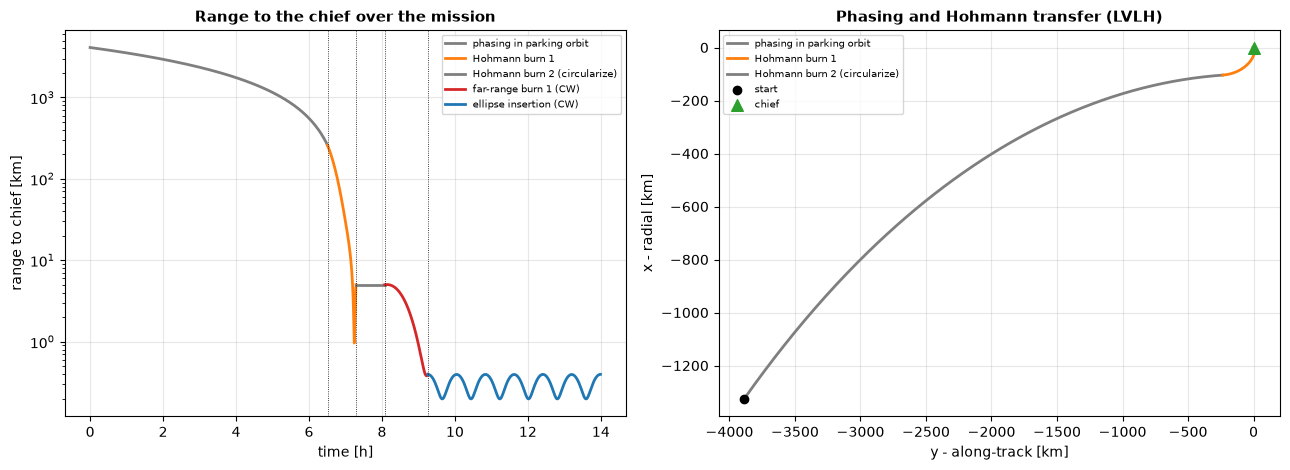

hold point after Hohmann 2 : x = -1.8 m, y = -5.000 km, speed relative to chief = 0.00 mm/s


In [5]:
colors = [COL_PARK, COL_HOH, COL_PARK, COL_HOP, COL_ELL]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
for leg, col in zip(legs, colors):
    ax.semilogy(leg["t"] / 3600, np.linalg.norm(leg["rel"][:3], axis=0) / 1e3, color=col, lw=2, label=leg["label"])
for e in events:
    ax.axvline(e["t"] / 3600, color="k", lw=0.6, ls=":")
ax.set_xlabel("time [h]")
ax.set_ylabel("range to chief [km]")
ax.set_title("Range to the chief over the mission")
ax.legend(fontsize=7, loc="upper right")

ax = axes[1]
for leg, col in list(zip(legs, colors))[:3]:
    ax.plot(leg["rel"][1] / 1e3, leg["rel"][0] / 1e3, color=col, lw=2, label=leg["label"])
ax.scatter([legs[0]["rel"][1, 0] / 1e3], [legs[0]["rel"][0, 0] / 1e3], color="k", zorder=5, label="start")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y - along-track [km]")
ax.set_ylabel("x - radial [km]")
ax.set_title("Phasing and Hohmann transfer (LVLH)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

hold = legs[2]["rel"]
print(f"hold point after Hohmann 2 : x = {hold[0, 0]:.1f} m, y = {hold[1, 0] / 1e3:.3f} km, "
      f"speed relative to chief = {np.linalg.norm(hold[3:, 0]) * 1e3:.2f} mm/s")

### The far-range approach and the safety ellipse

Zoom on the last two legs, in metres. The red arc is the CW-designed hop from the 5 km hold point; the blue curve is the deputy on the ellipse after the insertion burn, flown for three orbits with the nonlinear model. The dashed ellipse is the ideal closed-form ellipse through the point where the deputy actually arrived.

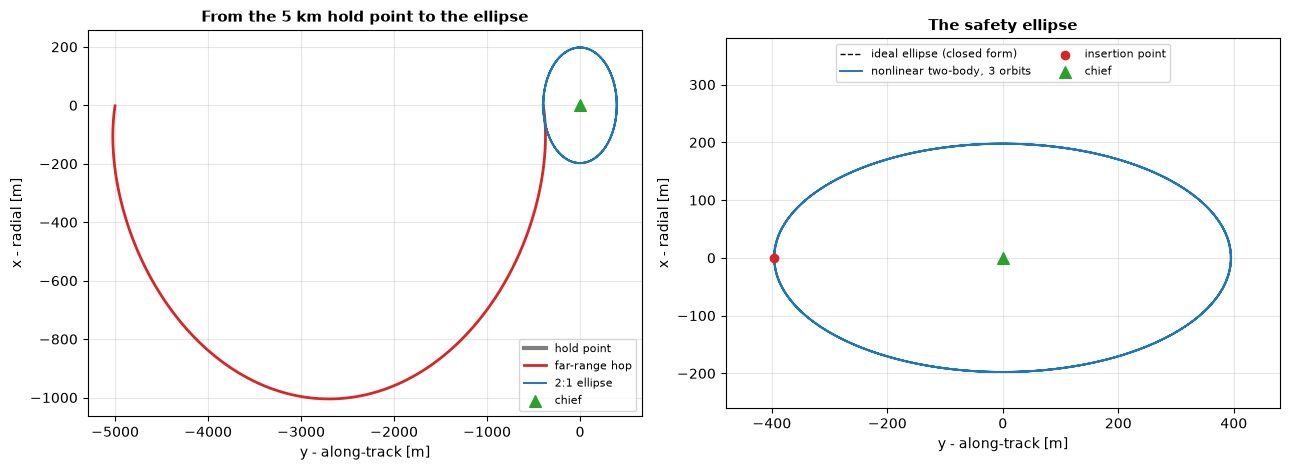

hop: planned arrival [ 1.2246468e-14 -4.0000000e+02] m, actual [  -0.49 -395.52] m  ->  miss = 4.51 m
ellipse actually inserted: rho = 197.76 m (design 200 m), x_off = 0.000 m
closure error after 3 orbits (nonlinear model): 0.804 m


In [6]:
hop, ell = legs[3], legs[4]

arrival = hop["rel"][:, -1]                 # state just before the insertion burn (LVLH, m, m/s)
miss = np.linalg.norm(arrival[:3] - state_design[:3])

ellipse_actual = drift_free_orbit_through(arrival[0], arrival[1])
phi = np.linspace(0, 2 * np.pi, 400)
ideal_x = ellipse_actual.rho * np.cos(phi)
ideal_y = -2 * ellipse_actual.rho * np.sin(phi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.plot(legs[2]["rel"][1], legs[2]["rel"][0], color=COL_PARK, lw=3, label="hold point")
ax.plot(hop["rel"][1], hop["rel"][0], color=COL_HOP, lw=2, label="far-range hop")
ax.plot(ell["rel"][1], ell["rel"][0], color=COL_ELL, lw=1.4, label="2:1 ellipse")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y - along-track [m]")
ax.set_ylabel("x - radial [m]")
ax.set_title("From the 5 km hold point to the ellipse")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
ax.plot(ideal_y, ideal_x, color="k", lw=1, ls="--", label="ideal ellipse (closed form)")
ax.plot(ell["rel"][1], ell["rel"][0], color=COL_ELL, lw=1.4, label="nonlinear two-body, 3 orbits")
ax.scatter([arrival[1]], [arrival[0]], color=COL_HOP, zorder=5, label="insertion point")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y - along-track [m]")
ax.set_ylabel("x - radial [m]")
ax.set_title("The safety ellipse")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-480, 480)
ax.set_ylim(-260, 380)
ax.legend(fontsize=8, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

start_ell = ell["rel"][:, 0]
after = relative_orbit_from_state(start_ell, n_c)
closure = np.linalg.norm(ell["rel"][:3, -1] - start_ell[:3])
print(f"hop: planned arrival {state_design[:2]} m, actual {np.round(arrival[:2], 2)} m  ->  miss = {miss:.2f} m")
print(f"ellipse actually inserted: rho = {after.rho:.2f} m (design {rho_ellipse:.0f} m), x_off = {after.x_off:.3f} m")
print(f"closure error after 3 orbits (nonlinear model): {closure:.3f} m")

Three numbers to read from this run:

- **The hop lands close to the design point.** The miss is the linearization error of a far-range CW design, measured against the nonlinear truth. The insertion burn takes it into account because it inserts from where the deputy really is, so the ellipse it produces is a little larger or smaller than designed (its radial semi-axis is printed above), but drift-free.
- **The ellipse is drift-free.** $x_{off}$ is essentially zero: nothing pushes the deputy away from the chief.
- **It stays closed to about a metre** over three orbits even with the full nonlinear two-body dynamics, so the passive safety of the ellipse is not an artifact of the linear model. That residual is the second-order error of CW at this ellipse size.

### Why the hop needed a curvature correction

The measured hold point is not quite where a V-bar hold point sits in the linear model. A deputy on *the same circular orbit*, 5 km behind, is in exact equilibrium with the chief, but in the chief's LVLH frame it sits at a small radial offset, $x \approx -y^2/(2a)$, simply because the frame's along-track axis is straight while the orbit is curved. That is about 1.8 m for 5 km. The CW equations do not know about curvature, so they read that 1.8 m as a real radial offset, which in the linear model means $x_{off}\neq 0$ and therefore a *drift* of tens of metres per orbit that does not exist. Designing the hop from the raw measured state builds that fake drift into the burn.

`hop_burn` removes the offset ($x \to x + y^2/2a$) before targeting. The next cell replays only the hop from the same hold state, with and without the correction.

In [7]:
chief_hold = legs[2]["chief"][:, -1]
deputy_hold = legs[2]["deputy"][:, -1]
rel_hold = inertial_to_lvlh(chief_hold, deputy_hold) * 1e3

naive_leg, _ = run_plan(chief_hold, deputy_hold, [("naive hop", hop_burn_naive, T_hop)],
                        two_body_dynamics_symbolic(), [MU_EARTH])
miss_naive = np.linalg.norm(naive_leg[0]["rel"][:3, -1] - state_design[:3])

print(f"radial offset of the hold point: measured x = {rel_hold[0]:.3f} m, "
      f"-y^2/(2a) = {-rel_hold[1] ** 2 / (2 * a_c * 1e3):.3f} m")
print(f"hop miss, designed from the raw measured state : {miss_naive:.2f} m")
print(f"hop miss, curvature offset removed (used above): {miss:.2f} m")

radial offset of the hold point: measured x = -1.817 m, -y^2/(2a) = -1.817 m
hop miss, designed from the raw measured state : 58.19 m
hop miss, curvature offset removed (used above): 4.51 m


The residual few metres are the genuine second-order error of the linear model over a 5 km hop. Removing them properly needs either a nonlinear (or curvilinear) targeting step or a corrective burn on approach, which is what closed-loop guidance is for.

## Delta-v budget

Every burn above is a line of the propellant budget of the end-to-end analysis. With a specific impulse it converts to propellant mass through the rocket equation, $m_{prop} = m_0\,(1 - e^{-\Delta v/(I_{sp}\,g_0)})$; that step, with margins and uncertainty, belongs to the budget layer. Here is just the $\Delta v$ side, split by phase.

In [8]:
groups = {
    "phasing + Hohmann": events[:2],
    "far-range approach + insertion": events[2:],
}
total = 0.0
print(f"{'phase':34s} {'dv [m/s]':>10s}")
for name, evs in groups.items():
    dv = sum(np.linalg.norm(e["dv"]) for e in evs) * 1e3
    total += dv
    print(f"{name:34s} {dv:10.3f}")
print(f"{'total':34s} {total:10.3f}")

print()
print("Same as a fraction: the approach and insertion cost "
      f"{sum(np.linalg.norm(e['dv']) for e in events[2:]) * 1e3:.3f} m/s, "
      f"about {100 * sum(np.linalg.norm(e['dv']) for e in events[2:]) / sum(np.linalg.norm(e['dv']) for e in events):.1f}% of the total.")

phase                                dv [m/s]
phasing + Hohmann                      55.949
far-range approach + insertion          1.231
total                                  57.181

Same as a fraction: the approach and insertion cost 1.231 m/s, about 2.2% of the total.


## What changes with J2

Everything so far used pure two-body gravity, where the ellipse is a perfect free orbit. Earth's oblateness (J2) acts differently on two spacecraft that are only a few hundred metres apart, and the difference accumulates. To see how big the effect is, take the exact state the two spacecraft have right after the insertion burn and fly the same three orbits with the J2 model instead.

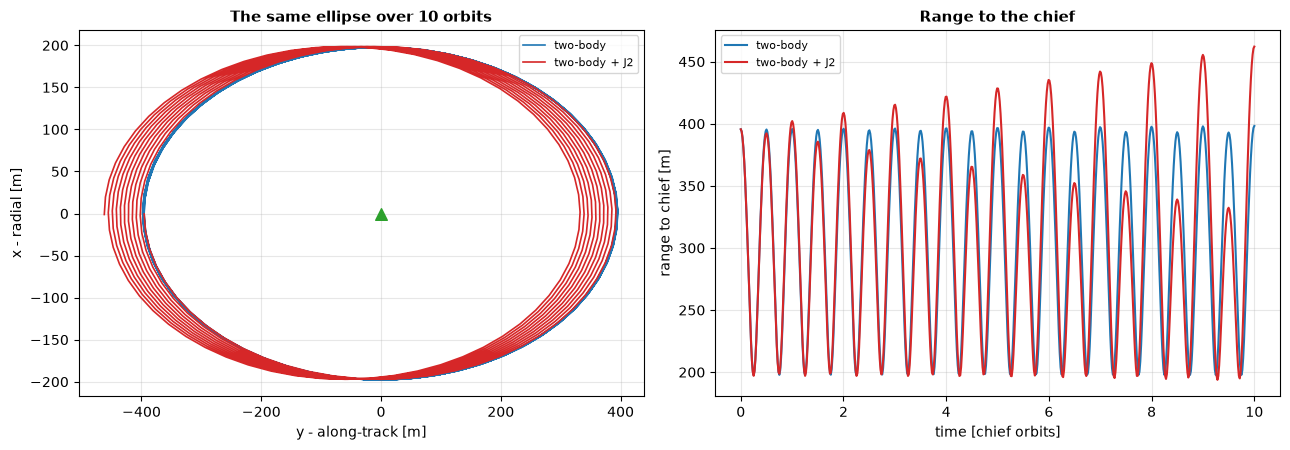

two-body : range stays within 198 - 398 m
with J2  : range within 194 - 462 m, final position differs from two-body by 64 m


In [9]:
ell = legs[4]
chief_start, deputy_start = ell["start_chief"], ell["start_deputy"]

def relative_history(dynamics, pars, n_orbits, pts=600):
    t = np.linspace(0.0, n_orbits * T, pts)
    c = propagate(dynamics, chief_start, t, pars=pars).y
    d = propagate(dynamics, deputy_start, t, pars=pars).y
    rel = np.array([inertial_to_lvlh(c[:, k], d[:, k]) for k in range(pts)]).T * 1e3
    return t, rel

n_orbits = 10
t_a, rel_2b = relative_history(two_body_dynamics_symbolic(), [MU_EARTH], n_orbits)
t_b, rel_j2 = relative_history(two_body_j2_dynamics_symbolic(), [MU_EARTH, J2_EARTH, R_EARTH], n_orbits)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.plot(rel_2b[1], rel_2b[0], color=COL_ELL, lw=1.2, label="two-body")
ax.plot(rel_j2[1], rel_j2[0], color=COL_HOP, lw=1.2, label="two-body + J2")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5)
ax.set_xlabel("y - along-track [m]")
ax.set_ylabel("x - radial [m]")
ax.set_title(f"The same ellipse over {n_orbits} orbits")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_a / T, np.linalg.norm(rel_2b[:3], axis=0), color=COL_ELL, label="two-body")
ax.plot(t_b / T, np.linalg.norm(rel_j2[:3], axis=0), color=COL_HOP, label="two-body + J2")
ax.set_xlabel("time [chief orbits]")
ax.set_ylabel("range to chief [m]")
ax.set_title("Range to the chief")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"two-body : range stays within {np.linalg.norm(rel_2b[:3], axis=0).min():.0f} - {np.linalg.norm(rel_2b[:3], axis=0).max():.0f} m")
print(f"with J2  : range within {np.linalg.norm(rel_j2[:3], axis=0).min():.0f} - {np.linalg.norm(rel_j2[:3], axis=0).max():.0f} m, "
      f"final position differs from two-body by {np.linalg.norm(rel_j2[:3, -1] - rel_2b[:3, -1]):.0f} m")

## Summary

- A complete approach was designed with analytical tools (Hohmann for phasing, CW targeting for the approach and the ellipse insertion) and flown with a nonlinear two-body model in heyoka. The deputy goes from a parking orbit about 4,000 km behind the chief to a 200 m x 400 m safety ellipse around it.
- The link between the two regimes is the frame transformation (`inertial_to_lvlh`) and the drift-free ellipse: phasing spends drift bought with a semi-major-axis difference, and the far-range burns end in a state with zero drift.
- Because the flight is nonlinear and the burns are computed from the *actual* state, the notebook measures real effects: the hop misses by a few metres, and the ellipse stays closed to under a metre over three orbits with two-body gravity.
- A linear model can be wrong in ways that are easy to miss. Feeding CW the raw measured state at the 5 km hold point built a fake drift into the burn (a 58 m miss); the cause was the 1.8 m radial offset that the curvature of the LVLH frame creates at that range, and removing it brought the miss to a few metres.
- With J2 the ellipse no longer stays closed. The passive safety of a perfect two-body ellipse is not a given in the real world.

**What this points to.** The J2 result is the entry point of the safety layer: the ellipse geometry ($\rho$, $y_c$, $x_{off}$) is what keep-out and passive-abort analyses will constrain, and the drift found here has to be handled by design (a J2-invariant ellipse, or a station-keeping budget). The $\Delta v$ table is the input of the budget layer, where it meets specific impulse, margins and navigation uncertainty.